# Chapter 4 — The Linear Layer (`matmul_forward` / `matmul_backward`)

> Course: **llm.c — Zero to Hero**, Chapter 4 of ~20.
> Builds on Chapters 2 and 3 (forward+backward pattern, OpenMP parallel-for).

LayerNorm in Chapter 3 was clever, but cheap — `O(BTC)` work. **Matmul is the opposite.** It dominates every Transformer's runtime: GPT-2 spends ~90% of its FLOPs in linear projections (QKV, attention output, two FFN layers per block, plus the final unembedding). When you optimize a Transformer, you mostly optimize matmul.

This chapter is also the first one where we will see *real* speedups from the optimizations. The naive triple-loop matmul is **embarrassingly slow** compared to a register-tiled, OpenMP-parallelized version — and that's still nowhere near a tuned BLAS or cuBLAS, which we'll meet on the GPU side later.

### Learning objectives

By the end of this chapter you will:

- Read and write the naive `matmul_forward_naive` (4 nested loops + `#pragma omp parallel for collapse(2)`).
- Understand the two key optimizations in `matmul_forward`: **collapsing `B*T` into a strided outer loop** and **register-tiling with `LOOP_UNROLL=8`** so each loaded `weight[i,o]` is reused 8 times.
- Derive and code the three matmul gradients: `dbias`, `dweight`, `dinp`.
- Explain *why* `matmul_backward` uses **two separate loops with different parallelization axes** instead of one fused loop.
- Benchmark naive vs optimized on a realistic shape and see a multi-× speedup live.


## 1. The Concept — A Linear Layer in Index Form

A linear layer takes a `C`-dim input vector and produces an `OC`-dim output vector via:

$$\text{out}_o = b_o + \sum_{i=0}^{C-1} W_{o,i} \cdot x_i$$

In `llm.c` we apply this *per `(b, t)` position* over a `(B, T, C)` activation tensor, sharing the same $W$ and $b$ everywhere:

$$\text{out}[b, t, o] = b_o + \sum_{i=0}^{C-1} W_{o,i} \cdot \text{inp}[b, t, i]$$

Two critical conventions:

- **Weight shape is `(OC, C)`**, i.e. row `o` is the linear combination that produces output channel `o`. This matches PyTorch's `nn.Linear` (which stores `weight: (OC, C)` and computes `x @ W.T + b`).
- **Bias shape is `(OC,)`**, broadcast over `(B, T)`. Same scatter-add pattern we saw in Chapter 3.

Because the same matrix is used at every `(b, t)`, you can think of it as a single big matmul:

$$\underbrace{\text{out}}_{(B \cdot T,\, OC)} = \underbrace{\text{inp}}_{(B \cdot T,\, C)} \cdot \underbrace{W^\top}_{(C,\, OC)} + \underbrace{b}_{(OC,)}$$

That `B*T` rolls into a single "rows" dimension. **Matmul does not care about batching** — it sees `(B*T, C) @ (C, OC)`.


## 2. PyTorch Baseline

In [1]:
import torch
import torch.nn as nn

torch.manual_seed(0)
B, T, C, OC = 2, 4, 8, 16

x = torch.randn(B, T, C)
lin = nn.Linear(C, OC)            # weight: (OC, C), bias: (OC,)

print("weight shape:", lin.weight.shape, "  bias shape:", lin.bias.shape)
out = lin(x)                      # equivalent to: x @ lin.weight.T + lin.bias
print("output shape:", out.shape) # (B, T, OC)

# Hand check on one position
b, t = 1, 2
manual = lin.bias + lin.weight @ x[b, t]   # (OC,) = (OC,) + (OC,C) @ (C,)
print("max diff:", (out[b, t] - manual).abs().max().item())


weight shape: torch.Size([16, 8])   bias shape: torch.Size([16])
output shape: torch.Size([2, 4, 16])
max diff: 5.960464477539063e-08


Notice that `nn.Linear(C, OC)` stores its weight as `(OC, C)` — the same convention as `llm.c`. PyTorch's forward computes `x @ W.T + b`, but you can equivalently think of it as `for each row x[b,t]: out[b,t] = W @ x[b,t] + b`, which is the form the C code uses.


## 3. Building Visual Intuition for Matmul

Before we read C code, let's build rock-solid intuition about *what the matmul actually computes*. Tensor indexing is where most bugs live — get it right here, in Python with full visualization, and the C version becomes a transcription exercise.

We'll use four debugging strategies that work for **any** tensor operation, not just matmul:

1. **The Shape Check** — verify dimensions line up before computing anything.
2. **Use Predictable Data** — `np.arange(...)` instead of `np.random.randn(...)` so you can read every value.
3. **Visualize as Heatmaps** — see which row/col is multiplying which.
4. **Master `einsum`** — express any tensor contraction in one line that mirrors the math.

Setup: import + tiny predictable tensors.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Tiny dimensions — small enough to see every number
B, T, C, OC = 2, 3, 4, 2     # Batch, Time, In Channels, Out Channels
N = B * T                     # 6 tokens total

# Predictable input: 1, 2, 3, ... so we can trace any computation by eye.
inp    = np.arange(1, B*T*C + 1, dtype=np.float32).reshape(B, T, C)
weight = np.arange(1, OC*C + 1, dtype=np.float32).reshape(OC, C)
bias   = np.array([100.0, 200.0], dtype=np.float32)

print("inp[0]  (one batch element, T=3 rows of C=4):")
print(inp[0])
print("\nweight (OC=2, C=4):")
print(weight)
print("\nbias (OC=2,):", bias)


inp[0]  (one batch element, T=3 rows of C=4):
[[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]]

weight (OC=2, C=4):
[[1. 2. 3. 4.]
 [5. 6. 7. 8.]]

bias (OC=2,): [100. 200.]


### Strategy 1 — The Shape Check

The single most useful debugging habit. Before computing, **trace shapes through every operation** and verify they line up.

The matmul rule: **(M, K) @ (K, N) = (M, N)**. The "inner" dimension `K` must match — it gets *contracted* (summed over). The outer dims `M` and `N` are preserved.

For our linear layer `out = inp @ weight.T + bias`:
- `inp`        : `(B, T, C)`  = `(2, 3, 4)`
- `weight.T`   : `(C, OC)`    = `(4, 2)`
- `inp @ weight.T` : `(B, T, OC)` = `(2, 3, 2)` ✓
- `bias` is `(OC,)` = `(2,)`, broadcasts over batch and time ✓

The matmul really collapses `B` and `T` into one "rows" dimension. The linear layer doesn't care which `(b, t)` a row came from — they're all just rows being projected.


In [3]:
# Print every shape so the math is concrete.
print(f"inp.shape       = {inp.shape}                        # (B, T, C)")
print(f"weight.shape    = {weight.shape}                           # (OC, C)")
print(f"weight.T.shape  = {weight.T.shape}                           # (C, OC)")
print(f"bias.shape      = {bias.shape}                            # (OC,)")
print()

# (B, T, C) @ (C, OC) → (B, T, OC) (NumPy broadcasts the leading dims)
out = inp @ weight.T + bias
print(f"out.shape       = {out.shape}                        # (B, T, OC)")

# Same op, viewed as a flat batch
inp_flat = inp.reshape(N, C)         # (6, 4)
out_flat = out.reshape(N, OC)        # (6, 2)
print()
print(f"inp_flat.shape  = {inp_flat.shape}                           # (B*T, C) = (N, C)")
print(f"out_flat.shape  = {out_flat.shape}                           # (B*T, OC) = (N, OC)")
print(f"-> the matmul is REALLY (N, C) @ (C, OC) = (N, OC)")


inp.shape       = (2, 3, 4)                        # (B, T, C)
weight.shape    = (2, 4)                           # (OC, C)
weight.T.shape  = (4, 2)                           # (C, OC)
bias.shape      = (2,)                            # (OC,)

out.shape       = (2, 3, 2)                        # (B, T, OC)

inp_flat.shape  = (6, 4)                           # (B*T, C) = (N, C)
out_flat.shape  = (6, 2)                           # (B*T, OC) = (N, OC)
-> the matmul is REALLY (N, C) @ (C, OC) = (N, OC)


### Strategy 2 — Predictable Data, Not Random

Random data is the *worst* possible thing to debug with. Every value looks the same — there's no way to tell which input contributed to which output.

Use `np.arange(...).reshape(...)` so each tensor element has a **meaning you can read** (1, 2, 3, ...). Then trace by hand: *"`out[0, 0, 0]` should be `inp[0,0,:] · weight[0,:] + bias[0]` = `1·1 + 2·2 + 3·3 + 4·4 + 100` = `30 + 100` = `130`."*

If it's `130`, you understand. If it isn't, you have a tractable bug because the numbers are *legible*.


In [4]:
# Hand-verify out[0, 0, 0] using the formula:
#   out[b,t,o] = bias[o] + sum_i inp[b,t,i] * weight[o, i]
b, t, o = 0, 0, 0
dot      = sum(inp[b, t, i] * weight[o, i] for i in range(C))
expected = bias[o] + dot
print(f"out[{b},{t},{o}] = bias[{o}] + Σ_i inp[{b},{t},i] * weight[{o},i]")
print(f"            = {bias[o]} + (1*1 + 2*2 + 3*3 + 4*4)")
print(f"            = {bias[o]} + {dot}")
print(f"            = {expected}")
print(f"  numpy says: {out[b, t, o]}")
assert out[b, t, o] == expected
print("  ✓ matches")


out[0,0,0] = bias[0] + Σ_i inp[0,0,i] * weight[0,i]
            = 100.0 + (1*1 + 2*2 + 3*3 + 4*4)
            = 100.0 + 30.0
            = 130.0
  numpy says: 130.0
  ✓ matches


### Strategy 3 — Visualize Matrices as Heatmaps

Eyes are the best debugging tool. Plotting tensors as 2D images forces you to see:

- Where the big values are
- Whether the structure makes sense (e.g. lower-triangular for causal masks, banded for convolutions, ...)
- Whether shapes match the layout you expected

Below is a 4-panel heatmap of the **forward** linear layer. Each output cell on the right is a dot product of one row from `inp_flat` (left) with one column from `weight.T` (middle-left).


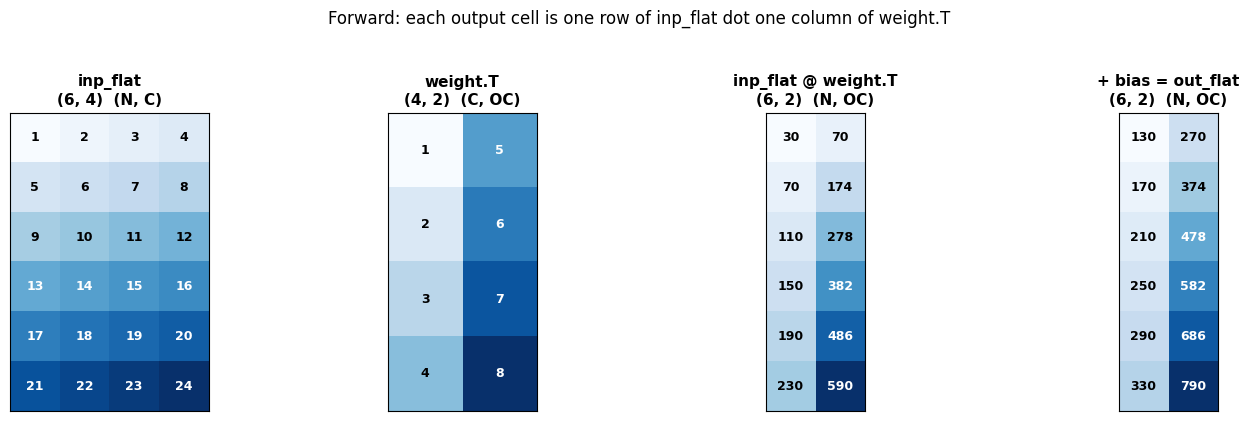

In [5]:
def plot_heatmap(ax, M, title, fmt='{:.0f}'):
    ax.imshow(M, cmap='Blues')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    thr = M.max() / 2.0
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            color = 'white' if M[i, j] > thr else 'black'
            ax.text(j, i, fmt.format(M[i, j]), ha='center', va='center',
                    color=color, fontweight='bold', fontsize=9)

# FORWARD visualization
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
plot_heatmap(axes[0], inp_flat,                f"inp_flat\n{inp_flat.shape}  (N, C)")
plot_heatmap(axes[1], weight.T,                f"weight.T\n{weight.T.shape}  (C, OC)")
plot_heatmap(axes[2], inp_flat @ weight.T,     f"inp_flat @ weight.T\n{(inp_flat @ weight.T).shape}  (N, OC)")
plot_heatmap(axes[3], out_flat,                f"+ bias = out_flat\n{out_flat.shape}  (N, OC)")
plt.suptitle("Forward: each output cell is one row of inp_flat dot one column of weight.T",
             fontsize=12, y=1.04)
plt.tight_layout(); plt.show()


Read it left to right: each cell of `inp_flat @ weight.T` is the dot product of the corresponding row of `inp_flat` with one column of `weight.T`. The bias adds element-wise after.

Now the **backward** — same trick. We'll preview the gradient `dweight = doutᵀ @ inp` (the formula you'll see in §10). Using a deliberately asymmetric `dout` (channel 0 = 1, channel 1 = 10) makes it obvious which input rows contribute where.


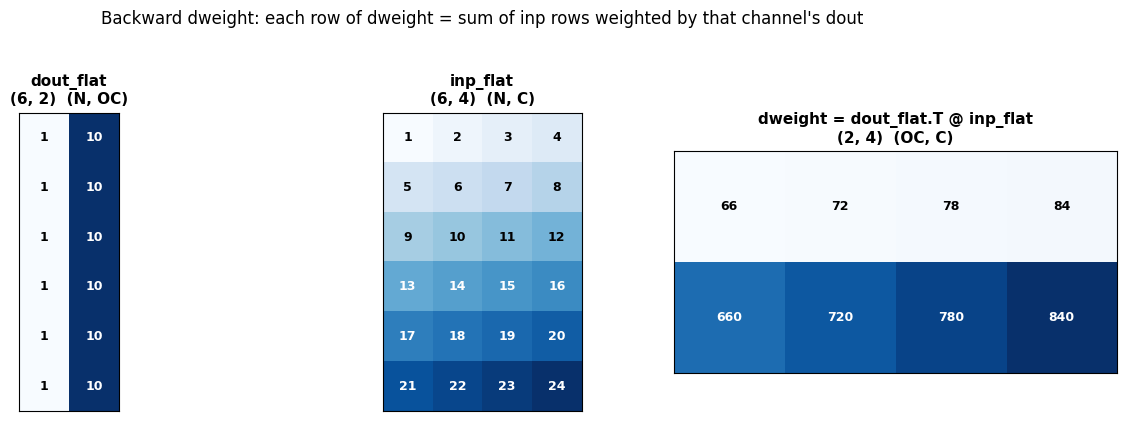

Sanity check the asymmetric structure:
  dweight[0, :]  (channel 0, dout=1)   = [66. 72. 78. 84.]
  expected: Σ inp rows * 1            = [66. 72. 78. 84.]
  dweight[1, :]  (channel 1, dout=10)  = [660. 720. 780. 840.]
  expected: Σ inp rows * 10           = [660. 720. 780. 840.]


In [6]:
# Backward visualization: dweight = dout.T @ inp_flat
# Asymmetric "incoming error" to highlight what dweight contains.
dout = np.zeros((B, T, OC), dtype=np.float32)
dout[:, :, 0] = 1.0
dout[:, :, 1] = 10.0
dout_flat = dout.reshape(N, OC)

# dweight[o, i] = Σ_{b,t} dout[b,t,o] * inp[b,t,i]
#              = (dout_flat.T @ inp_flat)[o, i]
dweight = dout_flat.T @ inp_flat   # (OC, N) @ (N, C) → (OC, C)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
plot_heatmap(axes[0], dout_flat,  f"dout_flat\n{dout_flat.shape}  (N, OC)")
plot_heatmap(axes[1], inp_flat,   f"inp_flat\n{inp_flat.shape}  (N, C)")
plot_heatmap(axes[2], dweight,    f"dweight = dout_flat.T @ inp_flat\n{dweight.shape}  (OC, C)")
plt.suptitle("Backward dweight: each row of dweight = sum of inp rows weighted by that channel's dout",
             fontsize=12, y=1.04)
plt.tight_layout(); plt.show()

print("Sanity check the asymmetric structure:")
print(f"  dweight[0, :]  (channel 0, dout=1)   = {dweight[0]}")
print(f"  expected: Σ inp rows * 1            = {inp_flat.sum(axis=0)}")
print(f"  dweight[1, :]  (channel 1, dout=10)  = {dweight[1]}")
print(f"  expected: Σ inp rows * 10           = {10 * inp_flat.sum(axis=0)}")


See how `dweight[1, :]` is exactly **10×** `dweight[0, :]`? That's the asymmetric `dout` paying off — the structure of the gradient is now visible at a glance.


### Strategy 4 — Master `einsum`

`np.einsum` (and `torch.einsum`) lets you express **any** tensor contraction in one line that mirrors the math.

The notation rule: letters appearing on **both** sides of `->` are kept in the output; letters appearing **only on the left** are *contracted* (summed).

Linear-layer math, four operations, four einsums:

| Operation | Index form | einsum |
|---|---|---|
| Forward | $\text{out}_{b,t,o} = \sum_i \text{inp}_{b,t,i} \cdot W_{o,i}$ | `'bti,oi->bto'` |
| `dweight` | $\text{dweight}_{o,i} = \sum_{b,t} \text{dout}_{b,t,o} \cdot \text{inp}_{b,t,i}$ | `'bto,bti->oi'` |
| `dinp` | $\text{dinp}_{b,t,i} = \sum_o \text{dout}_{b,t,o} \cdot W_{o,i}$ | `'bto,oi->bti'` |
| `dbias` | $\text{dbias}_o = \sum_{b,t} \text{dout}_{b,t,o}$ | `'bto->o'` |

Once you can write the einsum string, you've understood the operation. Conversely, when you read C code (§4 below) and see `out[bt*OC + o] += inp[bt*C + i] * weight[o*C + i]`, you can mentally translate it to `'bti,oi->bto'` and verify it's the right operation.


In [7]:
# Forward via einsum — the cleanest expression of the math
out_einsum = np.einsum('bti,oi->bto', inp, weight) + bias

# Forward via @ (the reshape-and-matmul form)
out_matmul = (inp.reshape(N, C) @ weight.T + bias).reshape(B, T, OC)

# All three backward gradients via einsum, one line each
dweight_einsum = np.einsum('bto,bti->oi', dout, inp)
dinp_einsum    = np.einsum('bto,oi->bti', dout, weight)
dbias_einsum   = np.einsum('bto->o',      dout)

# Cross-check: einsum and reshape+matmul produce identical results
assert np.allclose(out_einsum, out_matmul)
assert np.allclose(dweight_einsum, dout.reshape(N, OC).T @ inp.reshape(N, C))
assert np.allclose(dinp_einsum, (dout.reshape(N, OC) @ weight).reshape(B, T, C))
print("✓ einsum and reshape+matmul produce identical results for all 4 operations")
print()
print(f"dweight via 'bto,bti->oi'   {dweight_einsum.shape}:")
print(dweight_einsum)
print(f"\ndinp via 'bto,oi->bti'      {dinp_einsum.shape}")
print(f"dbias via 'bto->o'          {dbias_einsum.shape} = {dbias_einsum}")


✓ einsum and reshape+matmul produce identical results for all 4 operations

dweight via 'bto,bti->oi'   (2, 4):
[[ 66.  72.  78.  84.]
 [660. 720. 780. 840.]]

dinp via 'bto,oi->bti'      (2, 3, 4)
dbias via 'bto->o'          (2,) = [ 6. 60.]


### Why these strategies pay off in the C code

The C `matmul_forward_naive` you're about to read computes **the same einsum**:

```c
for (int b ...)
  for (int t ...)
    for (int o ...) {
        float val = bias[o];
        for (int i = 0; i < C; i++)
            val += inp[bt*C + i] * weight[o*C + i];   // <--- this IS 'bti,oi->bto'
        out[bt*OC + o] = val;
    }
```

The four nested loops are literally the four indices of `'bti,oi->bto'`: outer loops `b, t, o` keep those dims, the inner loop over `i` is the contraction. **If you can write the einsum, you can write the C.**

Same trick for backward: `'bto,bti->oi'` (`dweight`) and `'bto,oi->bti'` (`dinp`) tell you exactly which indices are loops vs. accumulations. We'll see those mapped to C in §11.

### Reusable rule of thumb

When debugging *any* tensor op — yours, PyTorch's, or `llm.c`'s — apply the four strategies in order:

1. Write down all input shapes and the expected output shape. (Shape check.)
2. Replace random tensors with `arange` so values are tractable. (Predictable data.)
3. `imshow()` the inputs and outputs to confirm the structure. (Heatmaps.)
4. Express the operation as an einsum string and prove it agrees with your implementation. (`einsum`.)

This works for matmul, attention, convolutions, scans — any operation whose definition can be written with index notation. We'll reach for it again in Chapter 6 (attention).


## 4. The Naive `matmul_forward_naive`

From [`train_gpt2.c`](train_gpt2.c) lines 163–182:

```c
void matmul_forward_naive(float* out,
                         const float* inp, const float* weight, const float* bias,
                         int B, int T, int C, int OC) {
    #pragma omp parallel for collapse(2)
    for (int b = 0; b < B; b++) {
        for (int t = 0; t < T; t++) {
            int bt = b * T + t;
            for (int o = 0; o < OC; o++) {
                float val = (bias != NULL) ? bias[o] : 0.0f;
                for (int i = 0; i < C; i++) {
                    val += inp[bt * C + i] * weight[o*C + i];
                }
                out[bt * OC + o] = val;
            }
        }
    }
}
```

Read it from outside in:

| Loop | What it does |
|---|---|
| `b`, `t` (parallelized via `collapse(2)`) | Each output position is independent — perfect for parallel-for. |
| `o` (output channel) | The output dimension we're writing into. |
| `i` (input channel) | The dot-product accumulation. This is the **innermost loop and the FLOP machine.** |

### Why `collapse(2)`

Without it, OpenMP would only parallelize the outermost `for (b)` loop — `B` iterations, often `B=4`, leaves you with at most 4 threads working. `collapse(2)` flattens `b × t` into a single iteration space of length `B*T`, so the runtime can spread `B*T` (often hundreds) iterations across all your cores.

Same parallelism rule from Chapter 2: each `(b, t)` writes to its **own** disjoint slice of `out`, so there's no race. The loop body only *reads* shared `inp`, `weight`, `bias` — multiple readers are always safe.

### Why this is slow

For each `(b, t, o, i)` quadruple, this code:
1. Loads `inp[bt*C + i]` from memory
2. Loads `weight[o*C + i]` from memory
3. Multiplies and accumulates into `val` (kept in a register)

The total work is `2 * B * T * OC * C` FLOPs (one multiply + one add per inner iteration). Total bytes loaded is roughly `B*T*OC*C * 8` (two floats per inner iteration). The **arithmetic intensity** is just **2 FLOPs / 8 bytes = 0.25 FLOPs/byte**, so we're memory-bandwidth-bound, not compute-bound.

The optimized version below raises that intensity by **reusing each loaded `weight[o, i]` 8 times**.


## 5. Translation Bridge

| PyTorch | C in `llm.c` |
|---|---|
| `nn.Linear(C, OC)` (module) | Three buffers: `weight: (OC,C)`, optional `bias: (OC,)`, no module wrapper |
| `x @ W.T + b` | Explicit `for o for i: out += inp[i] * W[o,i]` |
| `weight.T` (view, no copy) | We never transpose in code — the dot product just reads `weight[o*C + i]` in the order that *would* be `W.T[i, o]` |
| `bias=False` option | Pass `NULL` for `bias` — the C code checks `(bias != NULL)` per call |
| Internally calls cuBLAS / oneDNN | We hand-roll. The CUDA version (Chapter 14) will hand off to cuBLAS |

Mental model: **`nn.Linear.forward` *is* this 4-loop matmul, with bias and a transpose convention baked in.** Every time you write `nn.Linear(...)` in PyTorch, this code (or its GPU equivalent) runs underneath.


## 6. Compile and Verify the Naive Version Against PyTorch

In [ ]:
!mkdir -p course/ch04_build


In [ ]:
%%writefile course/ch04_build/matmul_forward_naive.c
#include <stdio.h>
#include <stdlib.h>
#include <omp.h>

void matmul_forward_naive(float* out, const float* inp, const float* weight, const float* bias,
                          int B, int T, int C, int OC) {
    #pragma omp parallel for collapse(2)
    for (int b = 0; b < B; b++) {
        for (int t = 0; t < T; t++) {
            int bt = b*T + t;
            for (int o = 0; o < OC; o++) {
                float val = (bias != NULL) ? bias[o] : 0.0f;
                for (int i = 0; i < C; i++) {
                    val += inp[bt*C + i] * weight[o*C + i];
                }
                out[bt*OC + o] = val;
            }
        }
    }
}

static void* rd(const char* p, size_t n) {
    FILE* f = fopen(p, "rb"); if (!f) { perror(p); exit(1); }
    void* b = malloc(n); size_t r = fread(b,1,n,f); (void)r; fclose(f); return b;
}

int main(int argc, char** argv) {
    if (argc != 5) { fprintf(stderr, "usage: B T C OC\n"); return 1; }
    int B=atoi(argv[1]), T=atoi(argv[2]), C=atoi(argv[3]), OC=atoi(argv[4]);
    float* inp    = (float*) rd("course/ch04_build/inp.bin",    (size_t)B*T*C*sizeof(float));
    float* weight = (float*) rd("course/ch04_build/weight.bin", (size_t)OC*C*sizeof(float));
    float* bias   = (float*) rd("course/ch04_build/bias.bin",   (size_t)OC*sizeof(float));
    float* out    = (float*) malloc((size_t)B*T*OC*sizeof(float));
    matmul_forward_naive(out, inp, weight, bias, B, T, C, OC);
    FILE* f = fopen("course/ch04_build/out_naive.bin","wb"); fwrite(out,4,(size_t)B*T*OC,f); fclose(f);
    free(inp); free(weight); free(bias); free(out); return 0;
}


In [ ]:
!gcc -O3 -Wall -fopenmp -o course/ch04_build/matmul_forward_naive course/ch04_build/matmul_forward_naive.c


In [ ]:
import numpy as np, torch, torch.nn as nn, subprocess
torch.manual_seed(0)
B, T, C, OC = 2, 4, 8, 16
x = torch.randn(B, T, C); lin = nn.Linear(C, OC)
nn.init.normal_(lin.weight); nn.init.normal_(lin.bias)
x.numpy().astype(np.float32).tofile("course/ch04_build/inp.bin")
lin.weight.detach().numpy().astype(np.float32).tofile("course/ch04_build/weight.bin")
lin.bias.detach().numpy().astype(np.float32).tofile("course/ch04_build/bias.bin")
subprocess.run(["./course/ch04_build/matmul_forward_naive", str(B),str(T),str(C),str(OC)], check=True)
out_c = np.fromfile("course/ch04_build/out_naive.bin", dtype=np.float32).reshape(B,T,OC)
out_pt = lin(x).detach().numpy()
print(f"max diff: {np.max(np.abs(out_c - out_pt)):.2e}")


## 7. The Optimized `matmul_forward` — Loop Unrolling

From [`train_gpt2.c`](train_gpt2.c) lines 184–229:

```c
void matmul_forward(float* out, const float* inp, const float* weight, const float* bias,
                    int B, int T, int C, int OC) {
    const int LOOP_UNROLL = 8;
    if (B*T % LOOP_UNROLL != 0) {
        // bail out if BT isn't a multiple of 8
        matmul_forward_naive(out, inp, weight, bias, B, T, C, OC);
        return;
    }

    // collapse the B and T loops into one and turn it into a strided loop.
    // then we can tile the inner loop, and reuse the loaded weight LOOP_UNROLL many times
    #pragma omp parallel for
    for (int obt = 0; obt < B*T; obt += LOOP_UNROLL) {
        for (int o = 0; o < OC; o++) {
            // we'll keep LOOP_UNROLL many results in registers
            float result[LOOP_UNROLL];
            for (int ibt = 0; ibt < LOOP_UNROLL; ibt++) {
                result[ibt] = (bias != NULL) ? bias[o] : 0.0f;
            }
            // inner loops. Because we do LOOP_UNROLL steps of inner bt, we can cache
            // the value of weight[i + o*C] and reuse it.
            for (int i = 0; i < C; i++) {
                float w = weight[i + o*C];               // <-- LOAD WEIGHT ONCE
                for (int ibt = 0; ibt < LOOP_UNROLL; ibt++) {
                    int bt = obt + ibt;
                    result[ibt] += inp[bt*C + i] * w;    // <-- USE IT 8 TIMES
                }
            }
            for (int ibt = 0; ibt < LOOP_UNROLL; ibt++) {
                int bt = obt + ibt;
                out[bt*OC + o] = result[ibt];
            }
        }
    }
}
```

Two distinct optimizations here.

### Optimization 1: Collapse `B,T` into a strided outer loop

Instead of `for b for t`, the code does `for (obt = 0; obt < B*T; obt += LOOP_UNROLL)`. This treats the `B*T` rows as one flat batch and processes them **8 at a time**. There is no longer a separate `b` and `t` — the variable `bt = obt + ibt` runs from `0` to `B*T - 1`.

### Optimization 2: Register tiling — reuse each loaded `weight[i,o]`

This is the key idea. Look at the innermost loop nest:

```c
for (int i = 0; i < C; i++) {
    float w = weight[i + o*C];                    // 1 load
    for (int ibt = 0; ibt < LOOP_UNROLL; ibt++) {
        result[ibt] += inp[bt*C + i] * w;          // 8 multiply-adds, all using the same w
    }
}
```

For each value of `(o, i)` we now do **8 multiplies-and-adds against a single loaded `w`**. The loaded weight value sits in a register and is reused 8 times before being discarded. Meanwhile, `result[0..7]` are 8 floats kept in registers (the compiler will generally do this — the array is small and never escapes).

The arithmetic intensity for the inner block:

- Loads: 1 weight + 8 input values = 9 loads = 36 bytes
- FLOPs: 8 multiplies + 8 adds = 16 FLOPs

That's **16 FLOPs / 36 bytes ≈ 0.44 FLOPs/byte** — almost 2× the naive code's intensity. With `-O3 -march=native`, the compiler will turn the inner loop into a single SIMD/AVX FMA instruction, so the practical speedup is bigger than 2×.

### Why fall back to naive when `B*T % 8 != 0`?

The unrolled code processes 8 rows at a time and assumes that's exact — there's no scalar tail handling. Rather than write tail code, `llm.c` simply calls `matmul_forward_naive` for those (rare) shapes. Real GPT-2 training has `B*T` divisible by 8 in practice.


## 8. Toy Example — See the Register Tile in Action

Let's make the register-tiling idea concrete by printing what happens inside the inner loop for a tiny example with `LOOP_UNROLL=4`.


In [ ]:
%%writefile course/ch04_build/toy_unroll.c
#include <stdio.h>

int main(void) {
    // Pretend we're doing one (o) row of the matmul, with C=3 inputs and 4 batch rows.
    const int UNROLL = 4, C = 3;
    float inp[4*3] = { 1, 2, 3,    // row 0
                       4, 5, 6,    // row 1
                       7, 8, 9,    // row 2
                       10,11,12};  // row 3
    float weight_row[3] = {0.1f, 0.2f, 0.3f};   // weight[o, :]
    float result[4] = {0,0,0,0};

    printf("Inner loop pattern (one weight value, four parallel updates):\n");
    for (int i = 0; i < C; i++) {
        float w = weight_row[i];
        printf("  i=%d  load w=%.1f, then for 4 rows:\n", i, w);
        for (int ibt = 0; ibt < UNROLL; ibt++) {
            float prev = result[ibt];
            result[ibt] += inp[ibt*C + i] * w;
            printf("    result[%d] += inp[%d,%d]=%.0f * %.1f -> %.2f (was %.2f)\n",
                   ibt, ibt, i, inp[ibt*C + i], w, result[ibt], prev);
        }
    }
    printf("Final results: %.1f %.1f %.1f %.1f\n",
           result[0], result[1], result[2], result[3]);
    return 0;
}


In [ ]:
!gcc -O2 -Wall -o course/ch04_build/toy_unroll course/ch04_build/toy_unroll.c && ./course/ch04_build/toy_unroll


You can see the access pattern: each row of `weight` is **streamed once through register `w`**, but is multiplied against **4 different rows of `inp` in parallel**. The 4 partial sums in `result[]` live in registers the entire time. That single load → multiple uses pattern is the whole point of register tiling.


## 9. Benchmark — Naive vs Unrolled

Let's compile both versions and time them on a realistically-sized matmul. We'll use a shape similar to the GPT-2 small QKV projection (`C → 3*C`) with a moderate `B*T`.


In [ ]:
%%writefile course/ch04_build/matmul_forward.c
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <time.h>
#include <omp.h>

void matmul_forward_naive(float* out, const float* inp, const float* weight, const float* bias,
                          int B, int T, int C, int OC) {
    #pragma omp parallel for collapse(2)
    for (int b = 0; b < B; b++)
        for (int t = 0; t < T; t++) {
            int bt = b*T + t;
            for (int o = 0; o < OC; o++) {
                float val = (bias != NULL) ? bias[o] : 0.0f;
                for (int i = 0; i < C; i++) val += inp[bt*C + i] * weight[o*C + i];
                out[bt*OC + o] = val;
            }
        }
}

void matmul_forward(float* out, const float* inp, const float* weight, const float* bias,
                    int B, int T, int C, int OC) {
    const int LOOP_UNROLL = 8;
    if ((B*T) % LOOP_UNROLL != 0) { matmul_forward_naive(out, inp, weight, bias, B,T,C,OC); return; }
    #pragma omp parallel for
    for (int obt = 0; obt < B*T; obt += LOOP_UNROLL) {
        for (int o = 0; o < OC; o++) {
            float result[LOOP_UNROLL];
            for (int k = 0; k < LOOP_UNROLL; k++) result[k] = (bias != NULL) ? bias[o] : 0.0f;
            for (int i = 0; i < C; i++) {
                float w = weight[i + o*C];
                for (int k = 0; k < LOOP_UNROLL; k++) {
                    int bt = obt + k;
                    result[k] += inp[bt*C + i] * w;
                }
            }
            for (int k = 0; k < LOOP_UNROLL; k++) {
                int bt = obt + k;
                out[bt*OC + o] = result[k];
            }
        }
    }
}

static void* rd(const char* p, size_t n) {
    FILE* f = fopen(p, "rb"); if (!f){perror(p); exit(1);}
    void* b = malloc(n); size_t r = fread(b,1,n,f); (void)r; fclose(f); return b;
}

static double now_s(void) { struct timespec t; clock_gettime(CLOCK_MONOTONIC, &t); return t.tv_sec + 1e-9*t.tv_nsec; }

int main(int argc, char** argv) {
    if (argc != 6) { fprintf(stderr, "usage: B T C OC iters\n"); return 1; }
    int B=atoi(argv[1]), T=atoi(argv[2]), C=atoi(argv[3]), OC=atoi(argv[4]);
    int iters=atoi(argv[5]);
    float* inp    = (float*) rd("course/ch04_build/inp.bin",    (size_t)B*T*C*sizeof(float));
    float* weight = (float*) rd("course/ch04_build/weight.bin", (size_t)OC*C*sizeof(float));
    float* bias   = (float*) rd("course/ch04_build/bias.bin",   (size_t)OC*sizeof(float));
    float* out    = (float*) malloc((size_t)B*T*OC*sizeof(float));

    // warmup
    matmul_forward_naive(out, inp, weight, bias, B,T,C,OC);
    matmul_forward(out, inp, weight, bias, B,T,C,OC);

    double t1 = now_s();
    for (int k = 0; k < iters; k++) matmul_forward_naive(out, inp, weight, bias, B,T,C,OC);
    double t2 = now_s();
    for (int k = 0; k < iters; k++) matmul_forward      (out, inp, weight, bias, B,T,C,OC);
    double t3 = now_s();

    double flops = 2.0 * (double)B*T*OC*C;   // 1 mul + 1 add per inner iter
    double naive_ms = 1e3 * (t2-t1)/iters;
    double opt_ms   = 1e3 * (t3-t2)/iters;
    double naive_gf = (flops/1e9) / ((t2-t1)/iters);
    double opt_gf   = (flops/1e9) / ((t3-t2)/iters);
    printf("Threads:           %d\n", omp_get_max_threads());
    printf("Shape:             B=%d T=%d C=%d OC=%d   (B*T=%d)\n", B,T,C,OC, B*T);
    printf("naive  : %.3f ms/iter   (%.1f GFLOP/s)\n", naive_ms, naive_gf);
    printf("unroll : %.3f ms/iter   (%.1f GFLOP/s)\n", opt_ms,   opt_gf);
    printf("speedup: %.2fx\n", naive_ms / opt_ms);

    // also save final output for correctness check
    matmul_forward(out, inp, weight, bias, B,T,C,OC);
    FILE* f = fopen("course/ch04_build/out_opt.bin","wb"); fwrite(out,4,(size_t)B*T*OC,f); fclose(f);
    free(inp); free(weight); free(bias); free(out); return 0;
}


In [ ]:
!gcc -O3 -Wall -march=native -fopenmp -o course/ch04_build/matmul_forward course/ch04_build/matmul_forward.c


In [ ]:
# Run a realistic-sized matmul. The GPT-2 small QKV projection is C=768 -> OC=3*C=2304.
import numpy as np, torch, subprocess
B, T, C, OC = 4, 256, 768, 2304     # B*T = 1024, divisible by 8
torch.manual_seed(0)
x = torch.randn(B, T, C); W = torch.randn(OC, C); b = torch.randn(OC)
x.numpy().astype(np.float32).tofile("course/ch04_build/inp.bin")
W.numpy().astype(np.float32).tofile("course/ch04_build/weight.bin")
b.numpy().astype(np.float32).tofile("course/ch04_build/bias.bin")
subprocess.run(["./course/ch04_build/matmul_forward", str(B),str(T),str(C),str(OC), "20"], check=True)

# Correctness check
out_opt = np.fromfile("course/ch04_build/out_opt.bin", dtype=np.float32).reshape(B,T,OC)
out_pt  = (x @ W.T + b).numpy()
print(f"\nmax diff vs PyTorch: {np.max(np.abs(out_opt - out_pt)):.2e}  (tolerance ~1e-3 due to float order-of-ops)")


You should see a comfortable speedup from the unrolled version — typically **2–4× faster** than naive, depending on your CPU. The exact number depends on cache size, vectorization width, and how aggressively the compiler turns the inner loop into AVX/AVX-512 FMA instructions.

> The numerical diff is `~1e-3`, looser than earlier chapters. This is **not** a bug — large matmuls accumulate hundreds of additions, and float-add is non-associative. PyTorch's BLAS sums in a different order than our unrolled C, so the last few bits differ. As long as the relative error is small, you're correct.


## 10. The Backward Pass — Math

Setup: $\text{out}_{b,t,o} = b_o + \sum_i W_{o,i} \cdot \text{inp}_{b,t,i}$

Given $\text{dout}_{b,t,o}$ flowing back from the next layer:

**Bias gradient (sum over batch):**
$$\frac{\partial L}{\partial b_o} = \sum_{b,t} \text{dout}_{b,t,o}$$

**Weight gradient (outer-product accumulation):**
$$\frac{\partial L}{\partial W_{o,i}} = \sum_{b,t} \text{dout}_{b,t,o} \cdot \text{inp}_{b,t,i}$$

**Input gradient (matmul with the transposed weight):**
$$\frac{\partial L}{\partial \text{inp}_{b,t,i}} = \sum_o \text{dout}_{b,t,o} \cdot W_{o,i}$$

All three are themselves matmul-like operations. In matrix form, viewing the data as `(B*T, *)` matrices:

| Gradient | Shape | Formula |
|---|---|---|
| `dbias` | `(OC,)`   | `dout.sum(axis=(0,1))` |
| `dweight` | `(OC, C)` | `dout.T @ inp` (treating both as `(B*T, *)`) |
| `dinp` | `(B*T, C)` | `dout @ weight` |

So a backward through `nn.Linear` is **2 matmuls + 1 reduction**. That's why a Transformer's backward FLOPs are roughly 2× the forward FLOPs.


## 11. The C `matmul_backward` — and Why It's Two Loops

From [`train_gpt2.c`](train_gpt2.c) lines 231–269. The whole function in plain prose:

```c
void matmul_backward(float* dinp, float* dweight, float* dbias,
                     const float* dout, const float* inp, const float* weight,
                     int B, int T, int C, int OC) {

    // ---------- LOOP A: compute dinp ----------
    // parallel over (b, t) — each thread writes its own row of dinp
    #pragma omp parallel for collapse(2)
    for (int b = 0; b < B; b++) {
        for (int t = 0; t < T; t++) {
            const float* dout_bt = dout + b*T*OC + t*OC;
            float* dinp_bt = dinp + b*T*C + t*C;
            for (int o = 0; o < OC; o++) {
                const float* wrow = weight + o*C;
                float d = dout_bt[o];
                for (int i = 0; i < C; i++) {
                    dinp_bt[i] += wrow[i] * d;
                }
            }
        }
    }

    // ---------- LOOP B: compute dweight and dbias ----------
    // parallel over o — each thread writes its own row of dweight (and one bias entry)
    #pragma omp parallel for
    for (int o = 0; o < OC; o++) {
        for (int b = 0; b < B; b++) {
            for (int t = 0; t < T; t++) {
                const float* dout_bt = dout + b*T*OC + t*OC;
                const float* inp_bt = inp + b*T*C + t*C;
                float* dwrow = dweight + o*C;
                float d = dout_bt[o];
                if (dbias != NULL) { dbias[o] += d; }
                for (int i = 0; i < C; i++) {
                    dwrow[i] += inp_bt[i] * d;
                }
            }
        }
    }
}
```

### Why two loops? **Different parallelism axes.**

You might think a single loop over `(b, t, o, i)` could compute all three gradients at once. It can — but you can't safely **parallelize** it. Watch:

- Parallel over `(b, t)`: ✅ safe for `dinp` (each thread owns one row), ❌ racy for `dweight` (every thread writes to every row of `dweight`)
- Parallel over `o`: ❌ racy for `dinp` (every thread writes to every row of `dinp`), ✅ safe for `dweight` (each thread owns one row)

There is no parallel axis that's safe for both. So `llm.c` writes the backward as two passes over the data — the first parallel over `(b, t)` for `dinp`, the second parallel over `o` for `dweight` and `dbias`. Each pass picks the parallelism axis where its writes don't collide.

The cost is reading `dout` and `inp` twice. The benefit is no atomics, no per-thread accumulators, no synchronization beyond the loop barriers — clean, fast, embarrassingly parallel.

### Why `+=` (not `=`)

Same reason as Chapter 3 — `dinp` is shared with the residual path, and `dweight`/`dbias` accumulate over all `(b, t)` positions. The caller (`gpt2_zero_grad`, Chapter 8) zeros these buffers before calling.


## 12. Compile and Verify Backward Against Autograd

In [ ]:
%%writefile course/ch04_build/matmul_backward.c
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <omp.h>

void matmul_backward(float* dinp, float* dweight, float* dbias,
                     const float* dout, const float* inp, const float* weight,
                     int B, int T, int C, int OC) {
    #pragma omp parallel for collapse(2)
    for (int b = 0; b < B; b++) {
        for (int t = 0; t < T; t++) {
            const float* dout_bt = dout + b*T*OC + t*OC;
            float* dinp_bt = dinp + b*T*C + t*C;
            for (int o = 0; o < OC; o++) {
                const float* wrow = weight + o*C;
                float d = dout_bt[o];
                for (int i = 0; i < C; i++) dinp_bt[i] += wrow[i] * d;
            }
        }
    }
    #pragma omp parallel for
    for (int o = 0; o < OC; o++) {
        for (int b = 0; b < B; b++) {
            for (int t = 0; t < T; t++) {
                const float* dout_bt = dout + b*T*OC + t*OC;
                const float* inp_bt  = inp  + b*T*C  + t*C;
                float* dwrow = dweight + o*C;
                float d = dout_bt[o];
                if (dbias != NULL) dbias[o] += d;
                for (int i = 0; i < C; i++) dwrow[i] += inp_bt[i] * d;
            }
        }
    }
}

static void* rd(const char* p, size_t n) {
    FILE* f = fopen(p, "rb"); if (!f){perror(p); exit(1);}
    void* b = malloc(n); size_t r = fread(b,1,n,f); (void)r; fclose(f); return b;
}

int main(int argc, char** argv) {
    if (argc != 5) return 1;
    int B=atoi(argv[1]), T=atoi(argv[2]), C=atoi(argv[3]), OC=atoi(argv[4]);
    float* inp    = (float*) rd("course/ch04_build/inp.bin",    (size_t)B*T*C*sizeof(float));
    float* weight = (float*) rd("course/ch04_build/weight.bin", (size_t)OC*C*sizeof(float));
    float* dout   = (float*) rd("course/ch04_build/dout.bin",   (size_t)B*T*OC*sizeof(float));
    float* dinp    = (float*) calloc((size_t)B*T*C,  sizeof(float));
    float* dweight = (float*) calloc((size_t)OC*C,   sizeof(float));
    float* dbias   = (float*) calloc((size_t)OC,     sizeof(float));
    matmul_backward(dinp, dweight, dbias, dout, inp, weight, B,T,C,OC);
    FILE* f;
    f=fopen("course/ch04_build/dinp.bin",   "wb"); fwrite(dinp,   4,(size_t)B*T*C, f); fclose(f);
    f=fopen("course/ch04_build/dweight.bin","wb"); fwrite(dweight,4,(size_t)OC*C,  f); fclose(f);
    f=fopen("course/ch04_build/dbias.bin",  "wb"); fwrite(dbias,  4,(size_t)OC,    f); fclose(f);
    free(inp); free(weight); free(dout); free(dinp); free(dweight); free(dbias); return 0;
}


In [ ]:
!gcc -O3 -Wall -fopenmp -o course/ch04_build/matmul_backward course/ch04_build/matmul_backward.c


In [ ]:
import numpy as np, torch, torch.nn as nn, subprocess
torch.manual_seed(0)
B, T, C, OC = 2, 4, 8, 16
x = torch.randn(B, T, C, requires_grad=True)
lin = nn.Linear(C, OC); nn.init.normal_(lin.weight); nn.init.normal_(lin.bias)
out = lin(x); dout = torch.randn_like(out); out.backward(dout)
x.detach().numpy().astype(np.float32).tofile("course/ch04_build/inp.bin")
lin.weight.detach().numpy().astype(np.float32).tofile("course/ch04_build/weight.bin")
dout.numpy().astype(np.float32).tofile("course/ch04_build/dout.bin")
subprocess.run(["./course/ch04_build/matmul_backward", str(B),str(T),str(C),str(OC)], check=True)
dinp_c    = np.fromfile("course/ch04_build/dinp.bin",    dtype=np.float32).reshape(B,T,C)
dweight_c = np.fromfile("course/ch04_build/dweight.bin", dtype=np.float32).reshape(OC,C)
dbias_c   = np.fromfile("course/ch04_build/dbias.bin",   dtype=np.float32).reshape(OC)
print(f"dinp    diff: {np.max(np.abs(dinp_c    - x.grad.numpy()         )):.2e}")
print(f"dweight diff: {np.max(np.abs(dweight_c - lin.weight.grad.numpy())):.2e}")
print(f"dbias   diff: {np.max(np.abs(dbias_c   - lin.bias.grad.numpy()  )):.2e}")


## 13. TODO Exercise 1 — Naive `matmul_forward`

The boilerplate sets up everything except the inner accumulation. Fill in the dot product.


In [ ]:
%%writefile course/ch04_build/exercise1.c
#include <stdio.h>
#include <stdlib.h>

void matmul_forward_naive(float* out, const float* inp, const float* weight, const float* bias,
                          int B, int T, int C, int OC) {
    #pragma omp parallel for collapse(2)
    for (int b = 0; b < B; b++) {
        for (int t = 0; t < T; t++) {
            int bt = b*T + t;
            for (int o = 0; o < OC; o++) {
                // TODO 1: initialize val from bias[o] (or 0 if bias is NULL)
                float val = 0.0f;

                // TODO 2: accumulate the dot product val += inp[bt,i] * weight[o,i]
                //         (remember inp is (B,T,C) flat and weight is (OC,C) flat)
                for (int i = 0; i < C; i++) {
                    // your code here
                }

                // TODO 3: write the result into out[bt, o]
                // out[?] = val;
            }
        }
    }
}

static void* rd(const char* p, size_t n){FILE*f=fopen(p,"rb");void*b=malloc(n);size_t r=fread(b,1,n,f);(void)r;fclose(f);return b;}

int main(int argc, char** argv) {
    int B=atoi(argv[1]), T=atoi(argv[2]), C=atoi(argv[3]), OC=atoi(argv[4]);
    float* inp    = (float*) rd("course/ch04_build/inp.bin",    (size_t)B*T*C*sizeof(float));
    float* weight = (float*) rd("course/ch04_build/weight.bin", (size_t)OC*C*sizeof(float));
    float* bias   = (float*) rd("course/ch04_build/bias.bin",   (size_t)OC*sizeof(float));
    float* out    = (float*) calloc((size_t)B*T*OC, sizeof(float));
    matmul_forward_naive(out, inp, weight, bias, B,T,C,OC);
    FILE* f = fopen("course/ch04_build/out_ex1.bin","wb"); fwrite(out,4,(size_t)B*T*OC,f); fclose(f);
    free(inp); free(weight); free(bias); free(out); return 0;
}


In [ ]:
# Auto-grade Exercise 1
import numpy as np, torch, torch.nn as nn, subprocess
torch.manual_seed(0); B, T, C, OC = 2, 4, 8, 16
x = torch.randn(B, T, C); lin = nn.Linear(C, OC)
nn.init.normal_(lin.weight); nn.init.normal_(lin.bias)
x.numpy().astype(np.float32).tofile("course/ch04_build/inp.bin")
lin.weight.detach().numpy().astype(np.float32).tofile("course/ch04_build/weight.bin")
lin.bias.detach().numpy().astype(np.float32).tofile("course/ch04_build/bias.bin")
subprocess.run(["gcc","-O3","-Wall","-fopenmp","-o","course/ch04_build/exercise1","course/ch04_build/exercise1.c"], check=True)
subprocess.run(["./course/ch04_build/exercise1", str(B),str(T),str(C),str(OC)], check=True)
out_ex = np.fromfile("course/ch04_build/out_ex1.bin", dtype=np.float32).reshape(B,T,OC)
err = np.max(np.abs(out_ex - lin(x).detach().numpy()))
print(f"max diff: {err:.2e}")
print("PASS" if err < 1e-5 else "FAIL — check the dot product / bias / write index")


### Solution to Exercise 1

In [ ]:
%%writefile course/ch04_build/exercise1_sol.c
#include <stdio.h>
#include <stdlib.h>

void matmul_forward_naive(float* out, const float* inp, const float* weight, const float* bias,
                          int B, int T, int C, int OC) {
    #pragma omp parallel for collapse(2)
    for (int b = 0; b < B; b++) {
        for (int t = 0; t < T; t++) {
            int bt = b*T + t;
            for (int o = 0; o < OC; o++) {
                float val = (bias != NULL) ? bias[o] : 0.0f;
                for (int i = 0; i < C; i++) {
                    val += inp[bt*C + i] * weight[o*C + i];
                }
                out[bt*OC + o] = val;
            }
        }
    }
}

static void* rd(const char* p, size_t n){FILE*f=fopen(p,"rb");void*b=malloc(n);size_t r=fread(b,1,n,f);(void)r;fclose(f);return b;}

int main(int argc, char** argv) {
    int B=atoi(argv[1]), T=atoi(argv[2]), C=atoi(argv[3]), OC=atoi(argv[4]);
    float* inp    = (float*) rd("course/ch04_build/inp.bin",    (size_t)B*T*C*sizeof(float));
    float* weight = (float*) rd("course/ch04_build/weight.bin", (size_t)OC*C*sizeof(float));
    float* bias   = (float*) rd("course/ch04_build/bias.bin",   (size_t)OC*sizeof(float));
    float* out    = (float*) calloc((size_t)B*T*OC, sizeof(float));
    matmul_forward_naive(out, inp, weight, bias, B,T,C,OC);
    FILE* f = fopen("course/ch04_build/out_ex1.bin","wb"); fwrite(out,4,(size_t)B*T*OC,f); fclose(f);
    free(inp); free(weight); free(bias); free(out); return 0;
}


In [ ]:
!gcc -O3 -Wall -fopenmp -o course/ch04_build/exercise1_sol course/ch04_build/exercise1_sol.c && ./course/ch04_build/exercise1_sol 2 4 8 16 && echo ran


## 14. TODO Exercise 2 — Backward `dinp`

The matmul backward has three gradients. The simplest one to write by hand is `dinp`. You're given the parallel-over-`(b,t)` loop scaffolding; fill in **the `dinp_bt[i] += weight[o,i] * dout_bt[o]` accumulation**.


In [ ]:
%%writefile course/ch04_build/exercise2.c
#include <stdio.h>
#include <stdlib.h>

void matmul_backward_dinp(float* dinp,
                          const float* dout, const float* weight,
                          int B, int T, int C, int OC) {
    #pragma omp parallel for collapse(2)
    for (int b = 0; b < B; b++) {
        for (int t = 0; t < T; t++) {
            const float* dout_bt = dout + b*T*OC + t*OC;
            float* dinp_bt = dinp + b*T*C + t*C;
            for (int o = 0; o < OC; o++) {
                const float* wrow = weight + o*C;   // (C,) — row o of weight
                float d = dout_bt[o];               // scalar dout[b,t,o]
                for (int i = 0; i < C; i++) {
                    // TODO: dinp_bt[i] += wrow[i] * d;
                }
            }
        }
    }
}

static void* rd(const char* p, size_t n){FILE*f=fopen(p,"rb");void*b=malloc(n);size_t r=fread(b,1,n,f);(void)r;fclose(f);return b;}

int main(int argc, char** argv) {
    int B=atoi(argv[1]), T=atoi(argv[2]), C=atoi(argv[3]), OC=atoi(argv[4]);
    float* weight = (float*) rd("course/ch04_build/weight.bin", (size_t)OC*C*sizeof(float));
    float* dout   = (float*) rd("course/ch04_build/dout.bin",   (size_t)B*T*OC*sizeof(float));
    float* dinp   = (float*) calloc((size_t)B*T*C, sizeof(float));
    matmul_backward_dinp(dinp, dout, weight, B,T,C,OC);
    FILE* f=fopen("course/ch04_build/dinp_ex2.bin","wb"); fwrite(dinp,4,(size_t)B*T*C,f); fclose(f);
    free(weight); free(dout); free(dinp); return 0;
}


In [ ]:
# Auto-grade Exercise 2
import numpy as np, torch, torch.nn as nn, subprocess
torch.manual_seed(0); B, T, C, OC = 2, 4, 8, 16
x = torch.randn(B, T, C, requires_grad=True)
lin = nn.Linear(C, OC); nn.init.normal_(lin.weight); nn.init.normal_(lin.bias)
out = lin(x); dout = torch.randn_like(out); out.backward(dout)
x.detach().numpy().astype(np.float32).tofile("course/ch04_build/inp.bin")
lin.weight.detach().numpy().astype(np.float32).tofile("course/ch04_build/weight.bin")
dout.numpy().astype(np.float32).tofile("course/ch04_build/dout.bin")
subprocess.run(["gcc","-O3","-Wall","-fopenmp","-o","course/ch04_build/exercise2","course/ch04_build/exercise2.c"], check=True)
subprocess.run(["./course/ch04_build/exercise2", str(B),str(T),str(C),str(OC)], check=True)
dinp_ex = np.fromfile("course/ch04_build/dinp_ex2.bin", dtype=np.float32).reshape(B,T,C)
err = np.max(np.abs(dinp_ex - x.grad.numpy()))
print(f"dinp diff: {err:.2e}")
print("PASS" if err < 1e-5 else "FAIL — check the dinp_bt[i] accumulation")


### Solution to Exercise 2

In [ ]:
%%writefile course/ch04_build/exercise2_sol.c
#include <stdio.h>
#include <stdlib.h>

void matmul_backward_dinp(float* dinp,
                          const float* dout, const float* weight,
                          int B, int T, int C, int OC) {
    #pragma omp parallel for collapse(2)
    for (int b = 0; b < B; b++) {
        for (int t = 0; t < T; t++) {
            const float* dout_bt = dout + b*T*OC + t*OC;
            float* dinp_bt = dinp + b*T*C + t*C;
            for (int o = 0; o < OC; o++) {
                const float* wrow = weight + o*C;
                float d = dout_bt[o];
                for (int i = 0; i < C; i++) dinp_bt[i] += wrow[i] * d;
            }
        }
    }
}

static void* rd(const char* p, size_t n){FILE*f=fopen(p,"rb");void*b=malloc(n);size_t r=fread(b,1,n,f);(void)r;fclose(f);return b;}

int main(int argc, char** argv) {
    int B=atoi(argv[1]), T=atoi(argv[2]), C=atoi(argv[3]), OC=atoi(argv[4]);
    float* weight = (float*) rd("course/ch04_build/weight.bin", (size_t)OC*C*sizeof(float));
    float* dout   = (float*) rd("course/ch04_build/dout.bin",   (size_t)B*T*OC*sizeof(float));
    float* dinp   = (float*) calloc((size_t)B*T*C, sizeof(float));
    matmul_backward_dinp(dinp, dout, weight, B,T,C,OC);
    FILE* f=fopen("course/ch04_build/dinp_ex2.bin","wb"); fwrite(dinp,4,(size_t)B*T*C,f); fclose(f);
    free(weight); free(dout); free(dinp); return 0;
}


In [ ]:
!gcc -O3 -Wall -fopenmp -o course/ch04_build/exercise2_sol course/ch04_build/exercise2_sol.c && ./course/ch04_build/exercise2_sol 2 4 8 16 && echo ran


## Recap

You now know:

- A `nn.Linear` layer in C is **a 4-loop matmul**: `(B*T, C) @ (C, OC)`. Forward FLOPs scale as `2*B*T*C*OC`.
- **`#pragma omp parallel for collapse(2)`** turns the outer `(b, t)` into a flat parallel iteration space — essential when `B` is small.
- **Register tiling with `LOOP_UNROLL=8`** raises arithmetic intensity by reusing each loaded `weight[o, i]` across 8 batch rows. Worth ~2–4× speedup at no extra memory cost.
- Matmul backward is **two matmuls** (`dinp = dout @ W`, `dweight = dout.T @ inp`) plus a sum (`dbias`). They are written as **two separate parallel loops with different parallel axes** because no single axis is race-free for both `dinp` and `dweight`.

This is also the chapter that makes clear why GPUs win: matmul is **the** parallel operation, and a GPU has thousands of multiply-add units instead of dozens. We'll meet cuBLAS in Chapter 14 and see how it gets close to peak hardware throughput.

### What's next

**Chapter 5 — GELU and Residual Connections.** A short, easy chapter after the heavy lifting of LayerNorm and matmul: pure elementwise ops with no reductions or fancy indexing. We'll see why GELU's "exact" form involves an `erf()` call, why GPT-2 uses the `tanh`-based approximation, and why residual connections are nearly free in compute but pivotal for trainability. Foreshadows GPU element-wise kernels in Part II.

When you're ready, say **"proceed to Chapter 5"**.
